# Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# Load Cleaned Dataset

In [2]:
df = pd.read_csv("../Output/cleaned_data.csv")

In [3]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
# Dataset Preview
df.head()

,TIMESLOT,DELHI,BRPL,BYPL,NDPL,NDMC,MES,Date,Year,Month,Day,Day_Name,Total_Consumption
0,00:00,4256.10,1762.03,970.96,1311.58,149.46,21.53,2022-04-06,2022,4,6,Wednesday,4215.56
1,00:05,4190.06,1730.40,959.13,1290.70,146.01,21.36,2022-04-06,2022,4,6,Wednesday,4147.60
2,00:10,4181.79,1726.67,961.50,1286.69,146.07,21.34,2022-04-06,2022,4,6,Wednesday,4142.27
3,00:15,4176.84,1714.84,964.93,1289.69,146.49,21.20,2022-04-06,2022,4,6,Wednesday,4137.15
4,00:20,4127.07,1700.86,950.89,1268.66,145.86,21.21,2022-04-06,2022,4,6,Wednesday,4087.48


In [5]:
# Data information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92268 entries, 0 to 92267
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TIMESLOT           92268 non-null  str           
 1   DELHI              92268 non-null  float64       
 2   BRPL               92268 non-null  float64       
 3   BYPL               92268 non-null  float64       
 4   NDPL               92268 non-null  float64       
 5   NDMC               92268 non-null  float64       
 6   MES                92268 non-null  float64       
 7   Date               92268 non-null  datetime64[us]
 8   Year               92268 non-null  int64         
 9   Month              92268 non-null  int64         
 10  Day                92268 non-null  int64         
 11  Day_Name           92268 non-null  str           
 12  Total_Consumption  92268 non-null  float64       
dtypes: datetime64[us](1), float64(7), int64(3), str(2)
memory usage: 9.2 MB


In [6]:
# Statistical Summary
df.describe()

,DELHI,BRPL,BYPL,NDPL,NDMC,MES,Date,Year,Month,Day,Total_Consumption
count,92268.000000,92268.000000,92268.000000,92268.000000,92268.000000,92268.000000,92268,92268.0,92268.000000,92268.000000,92268.000000
mean,4034.987428,1685.778753,880.116623,1224.368202,178.603913,27.776333,2022-06-22 22:42:17.651189,2022.0,6.237764,15.459292,3996.643824
min,1302.080000,470.730000,229.030000,352.520000,2.670000,0.000000,2022-01-01 00:00:00,2022.0,1.000000,1.000000,1289.780000
25%,3148.465000,1274.760000,671.430000,1005.010000,133.050000,21.900000,2022-03-30 00:00:00,2022.0,3.000000,8.000000,3117.810000
50%,4004.780000,1658.950000,891.750000,1234.950000,166.880000,27.370000,2022-06-22 00:00:00,2022.0,6.000000,15.000000,3966.650000
75%,4969.077500,2100.890000,1101.430000,1479.625000,210.020000,33.100000,2022-09-17 00:00:00,2022.0,9.000000,23.000000,4921.887500
max,7673.230000,3349.630000,1733.750000,2216.520000,398.580000,52.920000,2022-12-10 00:00:00,2022.0,12.000000,31.000000,7697.170000
std,1274.453448,571.747805,296.138142,350.679606,64.037130,8.350263,NaN,0.0,3.240786,8.788762,1262.399651


In [7]:
# Daily Total Consumption
daily_consumption = df.groupby('Date')['Total_Consumption'].sum()
daily_consumption.head()

Date
2022-01-01    831713.51
2022-01-02     72800.26
2022-01-03    850680.94
2022-01-04    676553.11
2022-01-06    582192.59
Name: Total_Consumption, dtype: float64

# Daily Consumption Plot

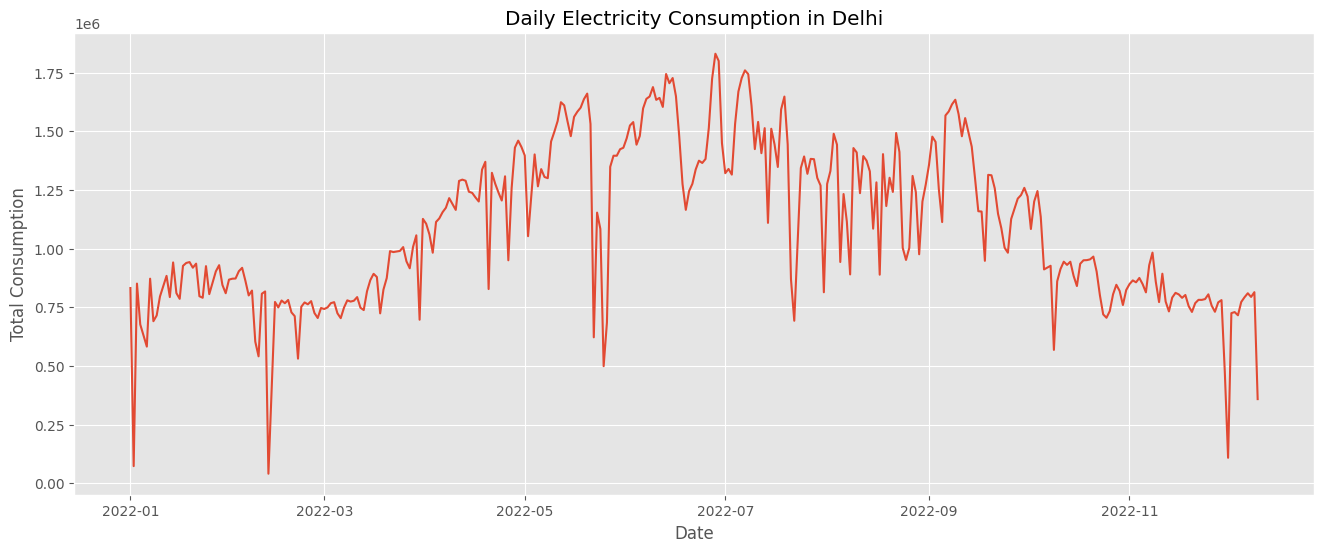

In [8]:
plt.figure(figsize=(16,6))
plt.plot(daily_consumption)
plt.title("Daily Electricity Consumption in Delhi")
plt.xlabel("Date")
plt.ylabel("Total Consumption")
plt.show()

# Highest Consumption Day

In [9]:
max_day = daily_consumption.idxmax()
max_value = daily_consumption.max()
print("Highest Consumption Day:", max_day)
print("Consumption:", max_value)

Highest Consumption Day: 2022-06-28 00:00:00
Consumption: 1830274.24


# Lowest Consumption Day

In [10]:
min_day = daily_consumption.idxmin()
min_value = daily_consumption.min()

print("Lowest Consumption Day:", min_day)
print("Consumption:", min_value)

Lowest Consumption Day: 2022-02-12 00:00:00
Consumption: 40407.200000000004


# WEEKLY ANALYSIS

In [11]:
# Create Week Column
df['Week'] = df['Date'].dt.isocalendar().week

In [12]:
# Weekly Consumption
weekly_consumption = df.groupby('Week')['Total_Consumption'].sum()

weekly_consumption.head()

Week
1    4386147.73
2    5009001.97
3    6248356.63
4    5217075.56
5    6095033.21
Name: Total_Consumption, dtype: float64

# Weekly Consumption Plot

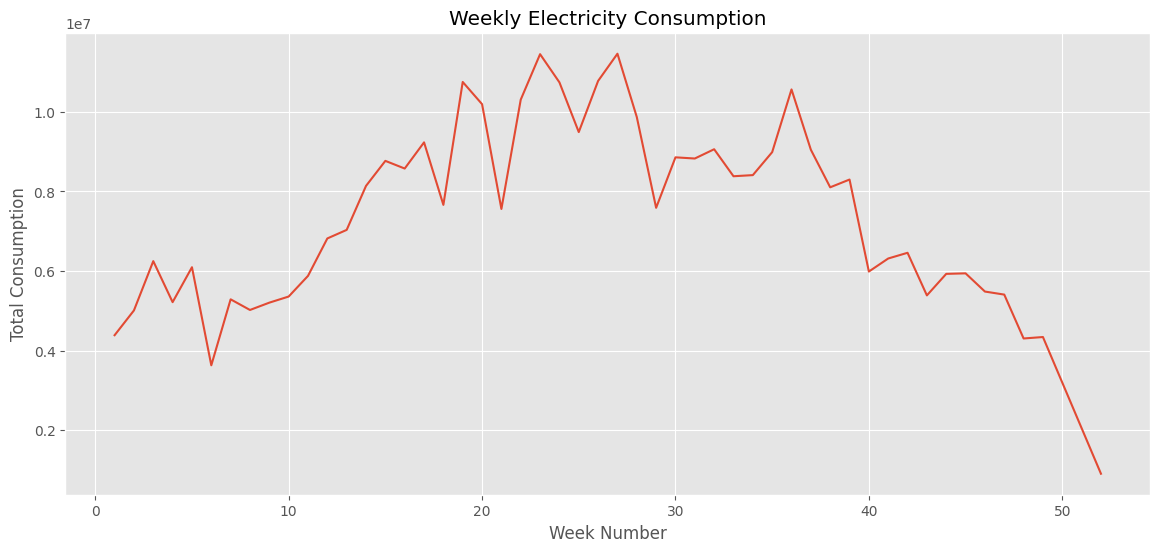

In [13]:
plt.figure(figsize=(14,6))

weekly_consumption.plot()

plt.title("Weekly Electricity Consumption")
plt.xlabel("Week Number")
plt.ylabel("Total Consumption")

plt.show()

# MONTHLY ANALYSIS

In [14]:
# Monthly Consumption
monthly_consumption = df.groupby('Month')['Total_Consumption'].sum()

monthly_consumption

Month
1     22632618.15
2     19912891.84
3     26398131.80
4     36468675.76
5     40417497.75
6     45942913.57
7     41754051.11
8     38129572.59
9     39250436.89
10    27274185.79
11    23962955.46
12     6618401.63
Name: Total_Consumption, dtype: float64

# Monthly Bar Chart

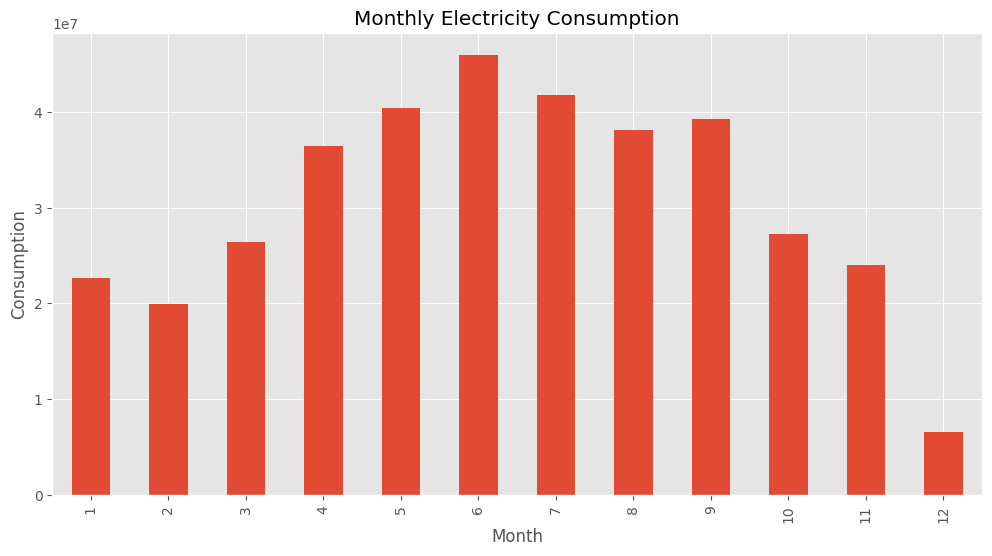

In [15]:
plt.figure(figsize=(12,6))

monthly_consumption.plot(kind='bar')

plt.title("Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Consumption")

plt.show()

In [16]:
# Highest Consumption Month
max_month = monthly_consumption.idxmax()
max_month_value = monthly_consumption.max()

print("Highest Consumption Month:", max_month)
print("Consumption:", max_month_value)

Highest Consumption Month: 6
Consumption: 45942913.57


# HOURLY ANALYSIS

In [17]:
# Extract Hour from TIMESLOT
df['Hour'] = df['TIMESLOT'].str.split(':').str[0]

df['Hour'] = df['Hour'].astype(int)

In [18]:
# Hourly Consumption
hourly_consumption = df.groupby('Hour')['Total_Consumption'].mean()

hourly_consumption

Hour
0     3936.165168
1     3701.621128
2     3517.923966
3     3366.053141
4     3283.930388
5     3301.474715
6     3470.420998
7     3650.698940
8     3775.945634
9     4055.170369
10    4353.050719
11    4449.023943
12    4448.711247
13    4294.421235
14    4445.121921
15    4499.552677
16    4419.214788
17    4341.977433
18    4257.248474
19    4196.152968
20    4115.012472
21    4080.789543
22    4126.027489
23    3995.273343
Name: Total_Consumption, dtype: float64

# Hourly Consumption Plot

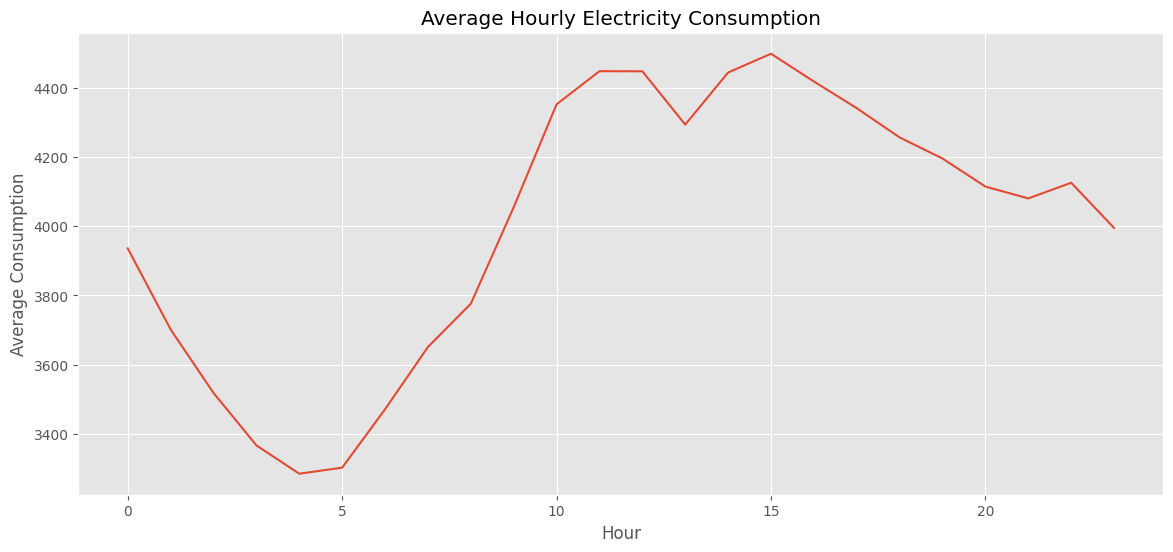

In [19]:
plt.figure(figsize=(14,6))

hourly_consumption.plot()

plt.title("Average Hourly Electricity Consumption")
plt.xlabel("Hour")
plt.ylabel("Average Consumption")

plt.show()

In [20]:
# Peak Hour Detection
peak_hour = hourly_consumption.idxmax()
peak_value = hourly_consumption.max()

print("Peak Hour:", peak_hour)
print("Average Consumption:", peak_value)

Peak Hour: 15
Average Consumption: 4499.552677386422


# YEARLY ANALYSIS

In [21]:
# Yearly Consumption
yearly_consumption = df.groupby('Year')['Total_Consumption'].sum()

yearly_consumption

Year
2022    3.687623e+08
Name: Total_Consumption, dtype: float64

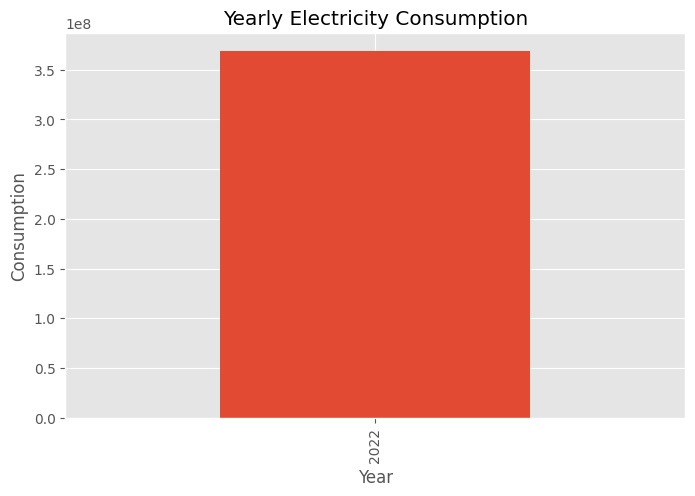

In [22]:
# Yearly Plot
plt.figure(figsize=(8,5))

yearly_consumption.plot(kind='bar')

plt.title("Yearly Electricity Consumption")
plt.xlabel("Year")
plt.ylabel("Consumption")

plt.show()

# DISTRIBUTION COMPANY ANALYSIS

In [23]:
# DISTRIBUTION COMPANY ANALYSIS
company_consumption = df[['BRPL', 'BYPL', 'NDPL', 'NDMC', 'MES']].sum()

company_consumption

BRPL    1.555434e+08
BYPL    8.120660e+07
NDPL    1.129700e+08
NDMC    1.647943e+07
MES     2.562867e+06
dtype: float64

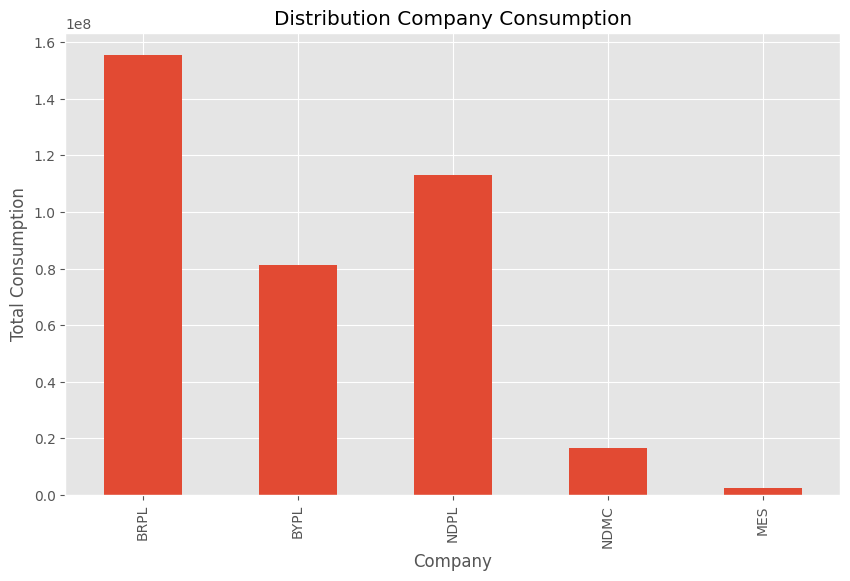

In [24]:
# Company-wise Plot
plt.figure(figsize=(10,6))

company_consumption.plot(kind='bar')

plt.title("Distribution Company Consumption")
plt.xlabel("Company")
plt.ylabel("Total Consumption")

plt.show()

# DAY-WISE ANALYSIS

In [25]:
# Day-wise Consumption
day_consumption = df.groupby('Day_Name')['Total_Consumption'].mean()

day_consumption

Day_Name
Friday       4050.760011
Monday       3997.709349
Saturday     3869.230133
Sunday       3742.016970
Thursday     4070.872151
Tuesday      4103.357659
Wednesday    4149.486465
Name: Total_Consumption, dtype: float64

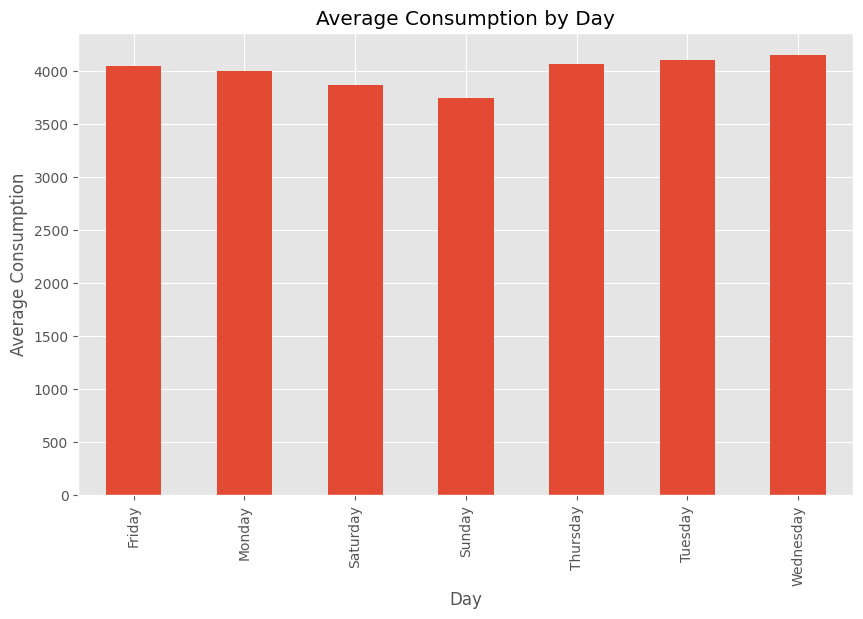

In [26]:
# Day-wise Plot
plt.figure(figsize=(10,6))

day_consumption.plot(kind='bar')

plt.title("Average Consumption by Day")
plt.xlabel("Day")
plt.ylabel("Average Consumption")

plt.show()

# CORRELATION ANALYSIS

In [27]:
# Correlation Matrix
correlation = df[['DELHI', 'BRPL', 'BYPL', 'NDPL', 'NDMC', 'MES', 'Total_Consumption']].corr()

correlation

,DELHI,BRPL,BYPL,NDPL,NDMC,MES,Total_Consumption
DELHI,1.000000,0.991677,0.993226,0.983739,0.784610,0.724381,0.999993
BRPL,0.991677,1.000000,0.985182,0.957023,0.731700,0.710406,0.991678
BYPL,0.993226,0.985182,1.000000,0.970263,0.756336,0.690637,0.993240
NDPL,0.983739,0.957023,0.970263,1.000000,0.792808,0.709568,0.983747
NDMC,0.784610,0.731700,0.756336,0.792808,1.000000,0.730165,0.784604
MES,0.724381,0.710406,0.690637,0.709568,0.730165,1.000000,0.724522
Total_Consumption,0.999993,0.991678,0.993240,0.983747,0.784604,0.724522,1.000000


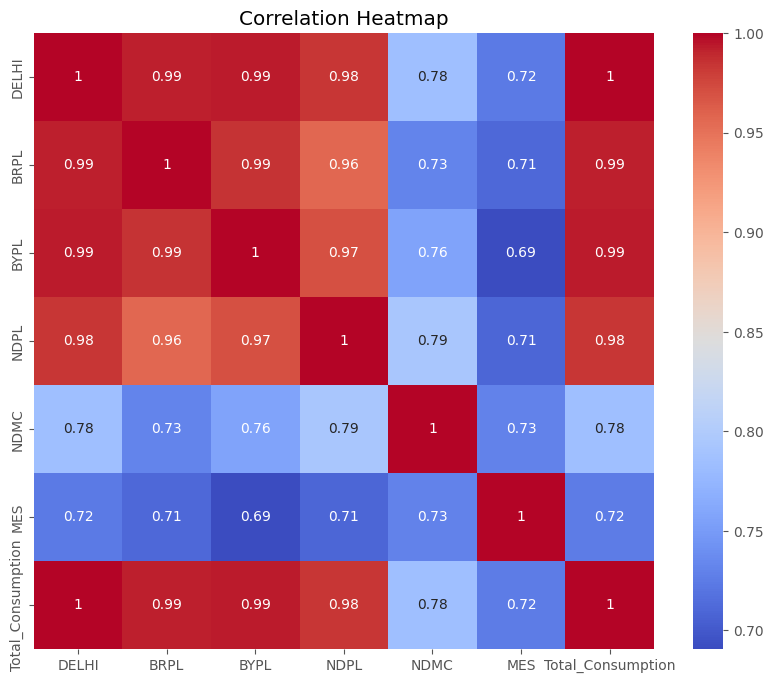

In [28]:
# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# PEAK LOAD ANALYSIS

In [29]:
# Top 10 Peak Consumption Records
top_peak = df.nlargest(10, 'Total_Consumption')

top_peak[['Date', 'TIMESLOT', 'Total_Consumption']]

,Date,TIMESLOT,Total_Consumption
26966,2022-06-29,15:00,7697.17
26967,2022-06-29,15:05,7600.28
26970,2022-06-29,15:20,7576.92
26969,2022-06-29,15:15,7575.88
26973,2022-06-29,15:35,7571.20
26968,2022-06-29,15:10,7570.03
26964,2022-06-29,14:50,7552.91
26972,2022-06-29,15:30,7549.20
26975,2022-06-29,15:45,7548.29
26965,2022-06-29,14:55,7545.61


<Figure size 1200x600 with 0 Axes>

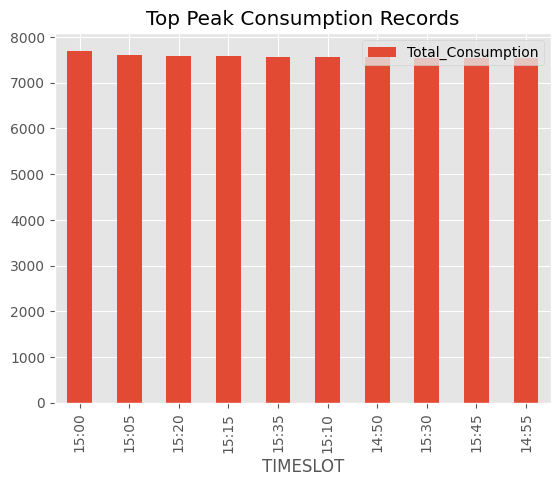

In [30]:
# Peak Consumption Plot
plt.figure(figsize=(12,6))

top_peak.plot(
    x='TIMESLOT',
    y='Total_Consumption',
    kind='bar'
)

plt.title("Top Peak Consumption Records")

plt.show()

# SUMMARY INSIGHTS

In [31]:
print("========== KEY INSIGHTS ==========")

print("\nHighest Daily Consumption:")
print(max_day, "-", max_value)

print("\nLowest Daily Consumption:")
print(min_day, "-", min_value)

print("\nPeak Hour:")
print(peak_hour)

print("\nHighest Consumption Month:")
print(max_month)

print("\nMost Consuming Distribution Company:")
print(company_consumption.idxmax())

========== KEY INSIGHTS ==========

Highest Daily Consumption:
2022-06-28 00:00:00 - 1830274.24

Lowest Daily Consumption:
2022-02-12 00:00:00 - 40407.200000000004

Peak Hour:
15

Highest Consumption Month:
6

Most Consuming Distribution Company:
BRPL


# Save Analysis Result

In [32]:
daily_consumption.to_csv("../output/daily_consumption.csv")

monthly_consumption.to_csv("../output/monthly_consumption.csv")

hourly_consumption.to_csv("../output/hourly_consumption.csv")

print("Analysis files saved successfully!")

Analysis files saved successfully!
